# Steam Reviews — Sentiment & Topic Analysis
**Course:**  Social Media and Network Analysis  
**Assignment 2**

This notebook covers the NLP text analysis component of our research question:

*How does the sentiment of Steam reviews vary between genres, and what topics characterise each genre's discourse?*

## 0. Install & Import Dependencies

In [3]:
!pip install vaderSentiment gensim pyLDAvis wordcloud nltk matplotlib seaborn --quiet

In [2]:
import os, json, glob, re, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.parsing.preprocessing import STOPWORDS as GENSIM_STOPWORDS

import scipy.linalg
import numpy as np
if not hasattr(scipy.linalg, 'triu'):
    scipy.linalg.triu = np.triu

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from wordcloud import WordCloud

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

STOP_WORDS = set(stopwords.words('english')).union(GENSIM_STOPWORDS)

GENRE_PALETTE = {'Horror': '#c0392b', 'RPG': '#2980b9', 'Strategy': '#27ae60'}

print('All imports successful.')

All imports successful.


## 1. Data Loading

Reviews were collected via the Steam API using the `steamreviews` Python package, stored as one JSON file per game.
We extract only the columns relevant to our research question and combine into a single DataFrame.

In [4]:
appid_dict = {
    '1622910' : ['Still wakes the deep', 'Horror'],
    '1196590' : ['Resident Evil Village', 'Horror'],
    '3180070' : ['No Im not a Human', 'Horror'],
    '541570'  : ['Sally Face - Episode one', 'Horror'],
    '1929610' : ['Demonologist','Horror'],
    '108710'  : ['Alan_Wake','Horror'],
    '238320'  : ['Outlast','Horror'],
    '506610'  : ["Five Nights at Freddy's: Sister location",'Horror'],
    '214490'  : ['Alien: Isolation','Horror'],
    '594330'  : ['Visage','Horror'],
    '2344520' : ['Diablo 4', "RPG"],
    '489830'  : ['The Elder Scrolls V: Skyrim Special Edition', "RPG"],
    '1245620' : ['ELDEN RING', "RPG"],
    '306130'  : ['The Elder Scrolls Online', "RPG"],
    '1151340' : ['Fallout 76', "RPG"],
    '39210'   : ['FINAL FANTASY XIV Online', "RPG"],
    '632470'  : ['Disco Elysium The Final Cut', "RPG"],
    '1091500' : ['Cyberpunk 2077', "RPG"],
    '1328670' : ['Mass Effect Legendary Edition', "RPG"],
    '1716740' : ['Starfield', "RPG"],
    '289070'  : ["Sid Meier's Civilization VI" , "Strategy"],
    '1142710' : ['Total War: WARHAMMER III' , "Strategy"],
    '281990'  : ['Stellaris' , "Strategy"],
    '1466860' : ['Age of Empires IV', "Strategy"],
    '394360'  : ['Hearts of Iron IV' , "Strategy"],
    '268500'  : ['XCOM 2', "Strategy"],
    '949230'  : ['Cities: Skylines II', "Strategy"],
    '323190'  : ['Frostpunk' , "Strategy"],
    '1158310' : ['Crusader Kings III', "Strategy"],
    '1363080' : ['Manor Lords', "Strategy"],
    }

data_path = "data"

rows = []

for filename in os.listdir(data_path):
    if filename.startswith("review_") and filename.endswith(".json"):
        
        # Extract appid from filename
        appid = filename.split("_")[1].split(".")[0]
        
        filepath = os.path.join(data_path, filename)
        
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
            
            for review in data.get("reviews", {}).values():

                author = review.get("author", {})
                rows.append({
                    "appid": appid,
                    "Game_name" : appid_dict[appid][0],
                    "Genre" : appid_dict[appid][1],
                    "timestamp_created": review.get("timestamp_created"),
                    "voted_up": review.get("voted_up"),
                    "steamid": author.get("steamid"),
                    "review": review.get("review"),
                    "votes_up": review.get("votes_up"),
                    "votes_funny": review.get("votes_funny"),
                    "weighted_vote_score": review.get("weighted_vote_score"),
                    "playtime_at_review": author.get("playtime_at_review"),
                    "written_during_early_access": review.get("written_during_early_access"),
                    "num_reviews": author.get("num_reviews")
                })

                ### FULL JSON TAGS ### if you want to use any other information
                # rows.append({
                #     "appid": appid,
                #     "Game_name" : appid_dict[appid][0],
                #     "Genre" : appid_dict[appid][1],
                #     "steamid": author.get("steamid"),
                #     "personaname": author.get("personaname"),
                #     "persona_status": author.get("persona_status"),
                #     "profile_url": author.get("profile_url"),
                #     "num_games_owned": author.get("num_games_owned"),
                #     "num_reviews": author.get("num_reviews"),
                #     "playtime_forever": author.get("playtime_forever"),
                #     "playtime_last_two_weeks": author.get("playtime_last_two_weeks"),
                #     "playtime_at_review": author.get("playtime_at_review"),
                #     "last_played": author.get("last_played"),
                #     "avatar": author.get("avatar"),

                #     "language": review.get("language"),
                #     "review": review.get("review"),
                #     "timestamp_created": review.get("timestamp_created"),
                #     "timestamp_updated": review.get("timestamp_updated"),
                #     "voted_up": review.get("voted_up"),
                #     "votes_up": review.get("votes_up"),
                #     "votes_funny": review.get("votes_funny"),
                #     "weighted_vote_score": review.get("weighted_vote_score"),
                #     "comment_count": review.get("comment_count"),
                #     "steam_purchase": review.get("steam_purchase"),
                #     "received_for_free": review.get("received_for_free"),
                #     "refunded": review.get("refunded"),
                #     "written_during_early_access": review.get("written_during_early_access"),
                #     "primarily_steam_deck": review.get("primarily_steam_deck"),
                #     "app_release_date": review.get("app_release_date"),
                #     "reactions": review.get("reactions"),
                # })  
# Create dataframe
df = pd.DataFrame(rows)

# Optional: convert timestamp to datetime
df["timestamp_created"] = pd.to_datetime(df["timestamp_created"], unit="s")

print(df.shape)
df.head()

(219611, 13)


,appid,Game_name,Genre,timestamp_created,voted_up,steamid,review,votes_up,votes_funny,weighted_vote_score,playtime_at_review,written_during_early_access,num_reviews
0,108710,Alan_Wake,Horror,2026-05-18 17:09:10,True,76561198715930868,This game runs incredibly well at max settings...,0,0,0.5,259,False,3
1,108710,Alan_Wake,Horror,2026-05-18 12:40:29,True,76561199196919919,"Nice story, even though bit confusing at the e...",0,0,0.5,1106,False,123
2,108710,Alan_Wake,Horror,2026-05-17 22:04:36,True,76561198402472807,"Overall, Alan Wake is a solid title, But falls...",0,0,0.5,1350,False,69
3,108710,Alan_Wake,Horror,2026-05-17 20:06:58,True,76561198739355493,pretty much a running simulator but a damn goo...,0,0,0.5,999,False,1
4,108710,Alan_Wake,Horror,2026-05-17 19:17:40,True,76561198101043758,Fun game but not for everyone. I think the gam...,0,0,0.5,475,False,33


### 1.1 Quick data quality check

In [6]:
print('Missing values:')
print(df.isnull().sum())
print()

Missing values:
appid                          0
Game_name                      0
Genre                          0
timestamp_created              0
voted_up                       0
steamid                        0
review                         0
votes_up                       0
votes_funny                    0
weighted_vote_score            0
playtime_at_review             0
written_during_early_access    0
num_reviews                    0
dtype: int64



In [59]:
print(f'Early access reviews : {df["written_during_early_access"].sum():,} '
      f'\nEarly access mean: {df["written_during_early_access"].mean():.1%}')
print(f'Median playtime at review (mins): {df["playtime_at_review"].median():.0f}')

Early access reviews : 6,929 
Early access mean: 3.2%
Median playtime at review (mins): 2974


## 2. Text Preprocessing

In [9]:
# Steam-specific noise words that dominate every topic without adding meaning
EXTRA_STOPWORDS = {
    'game', 'games', 'play', 'playing', 'played', 'steam',
    'recommend', 'recommended', 'fun', 'great', 'good', 'bad',
    'like', 'get', 'one', 'time', 'really', 'also', 'would',
    'much', 'well', 'still', 'even', 'though', 'little', 'way',
    'hours', 'hour', 'got', 'think', 'make', 'made', 'want',
    'know', 'dont', "don't", 'ive', "i've", 'its', "it's",
}
ALL_STOPS = STOP_WORDS.union(EXTRA_STOPWORDS)

In [10]:
def preprocess(text: str) -> list:
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)   # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)          # remove punctuation/numbers
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in ALL_STOPS and len(t) >= 3]

df['tokens']     = df['review'].apply(preprocess)
df['clean_text'] = df['tokens'].apply(lambda t: ' '.join(t))

## 3. Sentiment Analysis (VADER)

We use **VADER** (Valence Aware Dictionary and sEntiment Reasoner) — a lexicon and rule-based model designed for short, informal social media text. It returns a **compound score** ∈ [−1, 1]:
- ≥ 0.05 → **Positive**
- ≤ −0.05 → **Negative**
- Otherwise → **Neutral**

VADER is preferred over transformer models here because Steam reviews often contain informal language, slang, and mixed punctuation — conditions VADER handles well without requiring GPU resources.

In [13]:
analyser = SentimentIntensityAnalyzer()

In [14]:
print('Scoring sentiment with VADER')
scores = df['review'].apply(analyser.polarity_scores)
df['vader_neg']      = scores.apply(lambda x: x['neg'])
df['vader_neu']      = scores.apply(lambda x: x['neu'])
df['vader_pos']      = scores.apply(lambda x: x['pos'])
df['vader_compound'] = scores.apply(lambda x: x['compound'])

Scoring sentiment with VADER


In [15]:
#Function that assigns label
def to_label(score):
    if score >= 0.05:  return 'Positive'
    if score <= -0.05: return 'Negative'
    return 'Neutral'

In [16]:
df['vader_sentiment'] = df['vader_compound'].apply(to_label)
print(df['vader_sentiment'].value_counts())

vader_sentiment
Positive    142523
Neutral      45740
Negative     31348
Name: count, dtype: int64


### 3.1 Validate VADER against `voted_up`

Steam's `voted_up` field is a direct binary recommendation from the reviewer. We use it as a ground-truth proxy to validate how well VADER's compound score aligns with actual user intent.

In [26]:
non_neutral = df[df['vader_sentiment'] != 'Neutral']
agreement = (
    ((non_neutral['vader_sentiment'] == 'Positive') & (non_neutral['voted_up'] == True)) |
    ((non_neutral['vader_sentiment'] == 'Negative') & (non_neutral['voted_up'] == False))
)
print(f'VADER voted_up agreement (excl. Neutral): {agreement.mean():.1%}')

VADER voted_up agreement (excl. Neutral): 82.0%


In [28]:
ct = pd.crosstab(
    df['voted_up'].map({True: 'Thumbs Up', False: 'Thumbs Down'}),
    df['vader_sentiment'],
    normalize='index'
).round(3) * 100
print('\nVADER label distribution by voted_up (row %):')
print(ct)


VADER label distribution by voted_up (row %):
vader_sentiment  Negative  Neutral  Positive
voted_up                                    
Thumbs Down          42.8     14.3      42.9
Thumbs Up             9.5     21.9      68.6


The cross tabulation shows even split in thums up and thumbs down VADER labels.
This shows a Steam review pattern in which players write positively about a game but recommend against it due to specific issues like pricing, etc. VADER can only capture the textual sentiment and not the recommendation's intent.

In [34]:
#We'll also look at mean compound score split by early access and voted_up
print('Mean compound score by voted_up:')
print(df.groupby('voted_up')['vader_compound'].mean().round(3))

Mean compound score by voted_up:
voted_up
False    0.045
True     0.406
Name: vader_compound, dtype: float64


In [36]:
print('Mean compound score by early access:')
print(df.groupby('written_during_early_access')['vader_compound'].mean().round(3))

Mean compound score by early access:
written_during_early_access
False    0.351
True     0.466
Name: vader_compound, dtype: float64


### 3.2 Sentiment Distribution by Genre

C:\Users\karishma\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\karishma\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\karishma\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


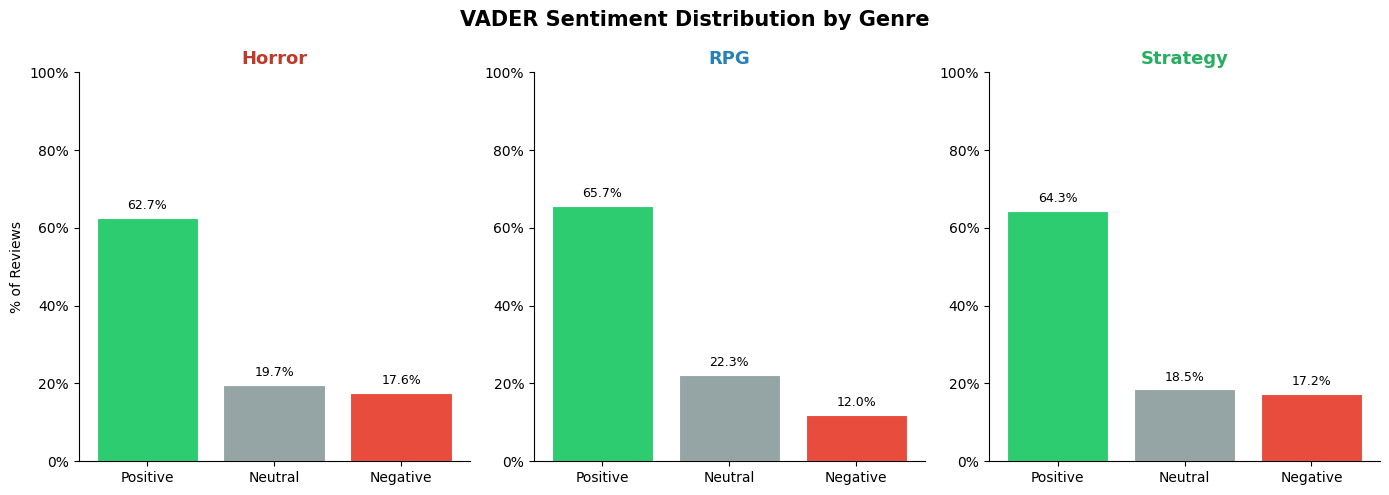

In [38]:
SENT_COLORS = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}
SENT_ORDER  = ['Positive', 'Neutral', 'Negative']

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
for ax, genre in zip(axes, ['Horror', 'RPG', 'Strategy']):
    sub    = df[df['Genre'] == genre]
    counts = sub['vader_sentiment'].value_counts().reindex(SENT_ORDER, fill_value=0)
    pct    = counts / counts.sum() * 100
    bars   = ax.bar(SENT_ORDER, pct,
                    color=[SENT_COLORS[s] for s in SENT_ORDER],
                    edgecolor='white', linewidth=0.8)
    ax.set_title(genre, fontsize=13, fontweight='bold', color=GENRE_PALETTE[genre])
    ax.set_ylabel('% of Reviews' if ax is axes[0] else '')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    for bar, val in zip(bars, pct):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('VADER Sentiment Distribution by Genre', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_by_genre.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Average Compound Score per Game

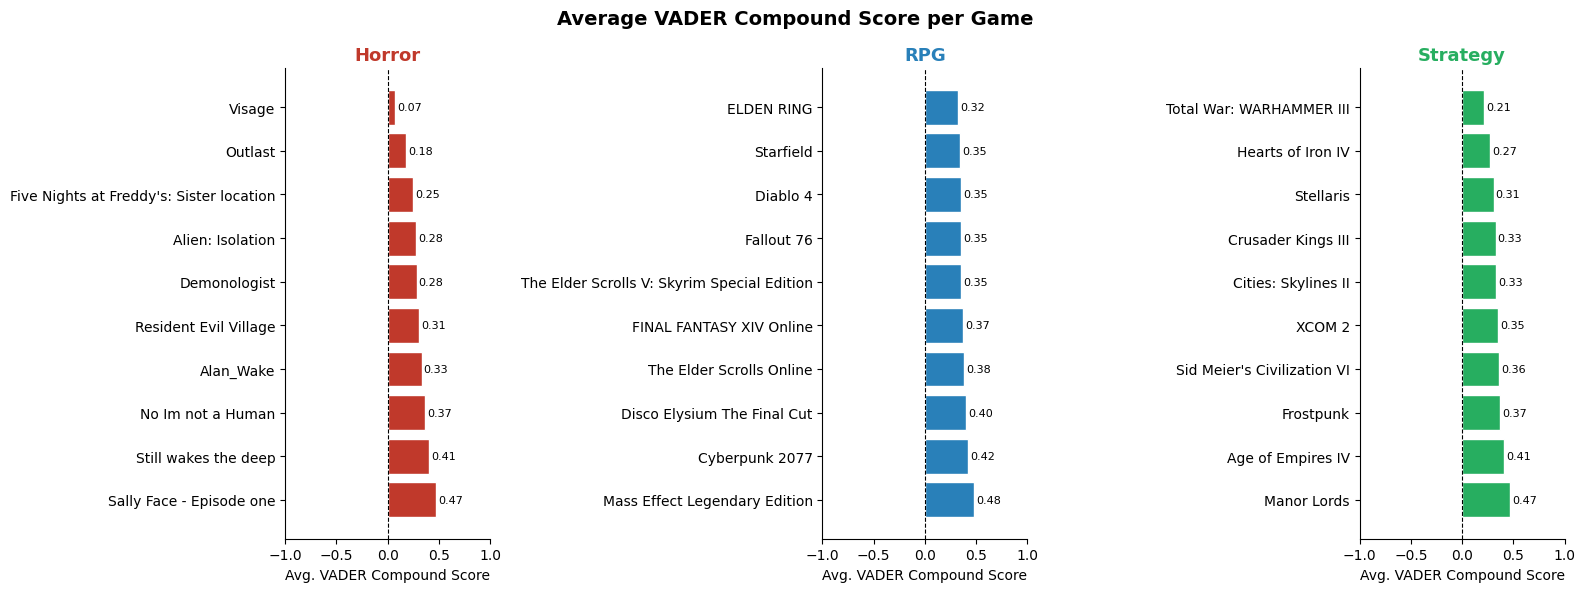

In [40]:
game_sent = (
    df.groupby(['Genre', 'Game_name'])['vader_compound']
    .mean().reset_index()
    .rename(columns={'vader_compound': 'avg_compound'})
    .sort_values(['Genre', 'avg_compound'], ascending=[True, False])
)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, genre in zip(axes, ['Horror', 'RPG', 'Strategy']):
    sub    = game_sent[game_sent['Genre'] == genre]
    colors = [GENRE_PALETTE[genre] if v >= 0 else '#e74c3c' for v in sub['avg_compound']]
    bars   = ax.barh(sub['Game_name'], sub['avg_compound'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(genre, fontsize=13, fontweight='bold', color=GENRE_PALETTE[genre])
    ax.set_xlabel('Avg. VADER Compound Score')
    ax.set_xlim(-1, 1)
    for bar, val in zip(bars, sub['avg_compound']):
        offset = 0.02 if val >= 0 else -0.02
        ax.text(val + offset, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Average VADER Compound Score per Game', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_by_game.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Does Playtime Correlate with Sentiment?

`playtime_at_review` (in minutes) tells us how long a reviewer had played before writing. This lets us test whether more invested players review differently.

In [44]:
# Convert to hours, cap outliers at 99th percentile for readability
df['playtime_hours'] = df['playtime_at_review'] / 60
cap = df['playtime_hours'].quantile(0.99)
df_pt = df[df['playtime_hours'] <= cap].copy()

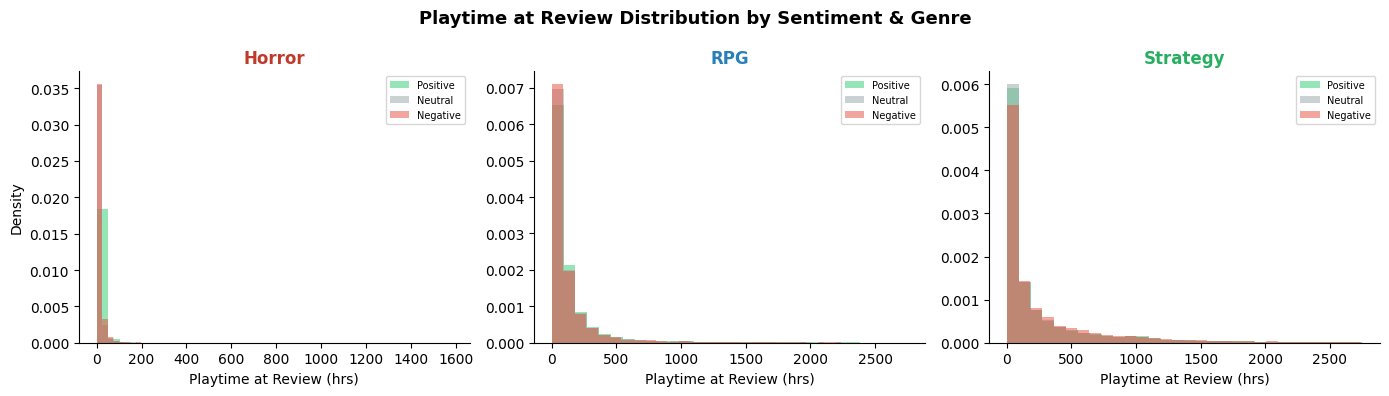

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, genre in zip(axes, ['Horror', 'RPG', 'Strategy']):
    sub = df_pt[df_pt['Genre'] == genre]
    for label, color in SENT_COLORS.items():
        grp = sub[sub['vader_sentiment'] == label]['playtime_hours']
        if len(grp) > 0:
            ax.hist(grp, bins=30, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(genre, fontsize=12, fontweight='bold', color=GENRE_PALETTE[genre])
    ax.set_xlabel('Playtime at Review (hrs)')
    ax.set_ylabel('Density' if ax is axes[0] else '')
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Playtime at Review Distribution by Sentiment & Genre',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('playtime_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

All genres have right-skewed playtime distributions; regardless of sentiment, the majority of reviewers write within the first 100 hours. Because the three sentiment groups vary in size, a raw count histogram would be misleading, thus densities are displayed instead.

In [47]:
# Correlation
print('Correlation between playtime_at_review and vader_compound (by genre):')
print(df.groupby('Genre')[['playtime_at_review','vader_compound']]
      .corr().unstack()['vader_compound']['playtime_at_review'].round(3))

Correlation between playtime_at_review and vader_compound (by genre):
Genre
Horror      0.024
RPG         0.003
Strategy   -0.002
Name: playtime_at_review, dtype: float64


### 3.5 Weighted Sentiment — Upvote-Weighted Compound Score

`weighted_vote_score` is Steam's own helpfulness metric for a review. We use `votes_up` to weight the compound score so that reviews the community found most helpful contribute more to the genre average.

In [50]:
def weighted_mean(group):
    weights = group['votes_up'] + 1   # +1 so zero-upvote reviews still count
    return np.average(group['vader_compound'], weights=weights)

weighted_by_genre = df.groupby('Genre').apply(weighted_mean).rename('weighted_compound')
unweighted_by_genre = df.groupby('Genre')['vader_compound'].mean().rename('unweighted_compound')
comparison = pd.concat([unweighted_by_genre, weighted_by_genre], axis=1).round(4)
print('Unweighted vs vote-weighted compound score by genre:')
print(comparison)

Unweighted vs vote-weighted compound score by genre:
          unweighted_compound  weighted_compound
Genre                                           
Horror                 0.3247             0.2797
RPG                    0.3784             0.3386
Strategy               0.3200             0.1919


Strategy has the biggest difference between weighted and unweighted sentiment, indicating that the reviews that Strategy communities upvotes the most are substantively more critical than the average review. This is consistent with the fact that strategy games draw seasoned, meticulous player bases resulting in comprehensive feedback.

### 3.6 Sentiment Over Time by Genre

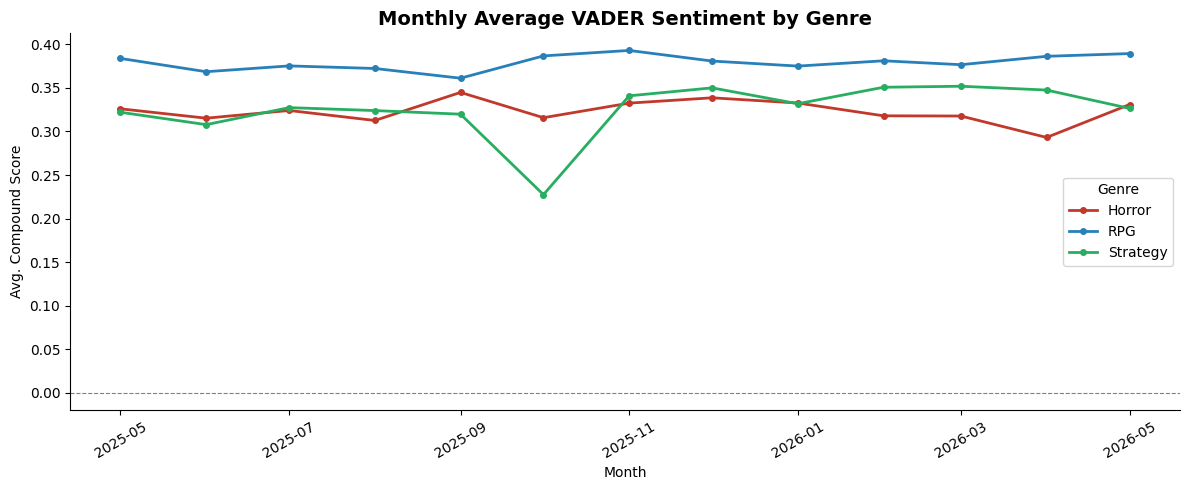

In [53]:
df['month'] = df['timestamp_created'].dt.to_period('M')
monthly = (
    df.groupby(['month', 'Genre'])['vader_compound']
    .mean().reset_index()
)
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
for genre, grp in monthly.groupby('Genre'):
    grp = grp.sort_values('month_dt')
    ax.plot(grp['month_dt'], grp['vader_compound'],
            label=genre, color=GENRE_PALETTE[genre],
            linewidth=2, marker='o', markersize=4)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Monthly Average VADER Sentiment by Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg. Compound Score')
ax.legend(title='Genre')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('sentiment_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

A loss of around 0.12 compound points in a single month probably indicates a particular event (DLC release, contentious patch, or community dispute) in one of the ten Strategy games, which is why the dramatic decline in October 2025 is worth noting. Because of this monthly granularity, it is impossible to link the decline to a particular game without additional research.